# Reconhecimento de Padrões

Priscilla Mayumi

Marcus Vinicius

João Paulo


In [229]:
# Importações necessárias / bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder


Dataset escolhido: https://archive.ics.uci.edu/dataset/2/adult

## Obtenção dos dados


In [230]:
# CÓDIGO ORIGINAL FORNECIDO:

from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [231]:
# =================================================================
# INFORMAÇÕES GERAIS, VISUALIZAÇÃO E CARACTERÍSTICAS
# =================================================================

# 1. Juntar as features (X) e targets (y) num único DataFrame
df = pd.concat([X, y], axis=1)

# Pegando a quantidade de linhas e colunas
linhas = df.shape[0]
colunas = df.shape[1]

print(f"O dataset possui {linhas} linhas e {colunas} colunas.\n")

# 2. Features (variáveis independentes)
features = X.columns.tolist()
qtd_features = len(features)


print(f"\n São {qtd_features} features:")
for feature in features:
    print(f"- {feature}")

# 3. Listando o Target (variável dependente / classe alvo)
targets = y.columns.tolist()

print(f"\nTarget (variável dependente):")
for target in targets:
    print(f"- {target}")

print("\n--- Sample tabela ---")
display(df.head())

O dataset possui 48842 linhas e 15 colunas.


 São 14 features:
- age
- workclass
- fnlwgt
- education
- education-num
- marital-status
- occupation
- relationship
- race
- sex
- capital-gain
- capital-loss
- hours-per-week
- native-country

Target (variável dependente):
- income

--- Sample tabela ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Limpeza dos dados


In [232]:
print("--- Existem outliers e missing values ---")

# Calcula o número de instâncias com missing values
num_instances_with_missing = df.isnull().any(axis=1).sum()
print(f"Número de instâncias com missing values em qualquer posição: {num_instances_with_missing}")

# Missing values por coluna
missing_por_coluna = df.isnull().sum().sort_values(ascending=False)
print("Missing values por coluna:")
print(missing_por_coluna)


--- Existem outliers e missing values ---
Número de instâncias com missing values em qualquer posição: 1221
Missing values por coluna:
occupation        966
workclass         963
native-country    274
fnlwgt              0
education           0
education-num       0
age                 0
marital-status      0
relationship        0
sex                 0
race                0
capital-gain        0
capital-loss        0
hours-per-week      0
income              0
dtype: int64


In [233]:
# Remoção de linhas com missing values
before = len(df)
df = df.dropna()
after = len(df)
print(f"Linhas removidas por missing values: {before - after}")
print(f"Linhas restantes: {after}")


Linhas removidas por missing values: 1221
Linhas restantes: 47621


In [234]:
# Verificação de linhas duplicadas (idênticas)
num_dups = df.duplicated().sum()
print(f"Número de linhas duplicadas: {num_dups}")


Número de linhas duplicadas: 29


In [235]:
# Remoção de linhas duplicadas
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Linhas removidas por duplicidade: {before - after}")
print(f"Linhas restantes: {after}")


Linhas removidas por duplicidade: 29
Linhas restantes: 47592


## EDA


In [236]:
print("--- 1. TIPOS DE DADOS DAS FEATURES ---")
tipos_dados = df.dtypes.value_counts()
print(tipos_dados)

--- 1. TIPOS DE DADOS DAS FEATURES ---
str      9
int64    6
Name: count, dtype: int64


In [237]:
print('### Classificação das Variáveis ###')

continuas_razao = []
discretas_ordinais = []
discretas_nominais = []

for feature in df.columns:
    if feature == '_target_bin':
        continue
    if feature in ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']:
        continuas_razao.append(feature)
    elif feature in ['education-num', 'education']:
        discretas_ordinais.append(feature)
    elif feature in ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']:
        discretas_nominais.append(feature)
    else:
        print(f"Warning: Feature '{feature}' not classified.")

print('Contínuas (Razão):')
for f in continuas_razao:
    print(f"- {f}")

print('Discretas Ordinais:')
for f in discretas_ordinais:
    print(f"- {f}")

print('Discretas Nominais:')
for f in discretas_nominais:
    print(f"- {f}")


### Classificação das Variáveis ###
Contínuas (Razão):
- age
- fnlwgt
- capital-gain
- capital-loss
- hours-per-week
Discretas Ordinais:
- education
- education-num
Discretas Nominais:
- workclass
- marital-status
- occupation
- relationship
- race
- sex
- native-country


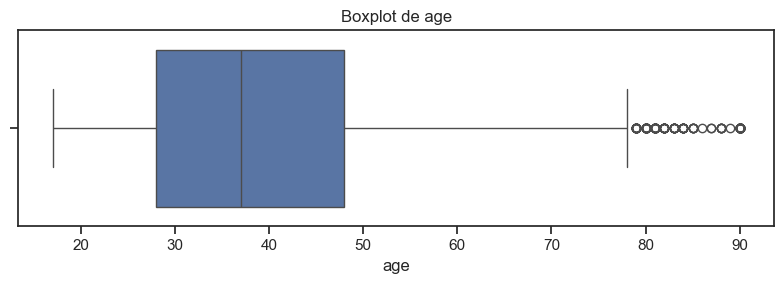

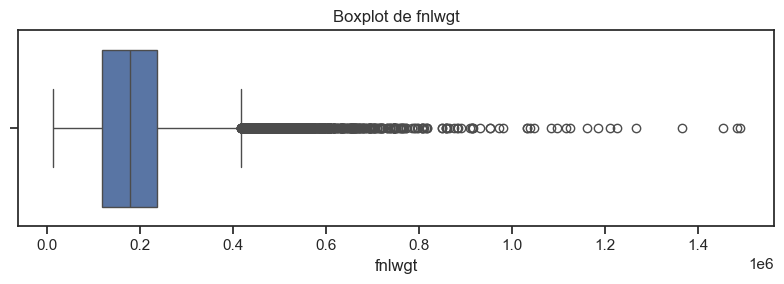

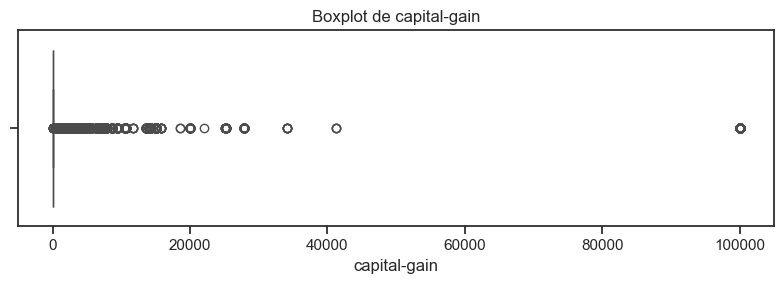

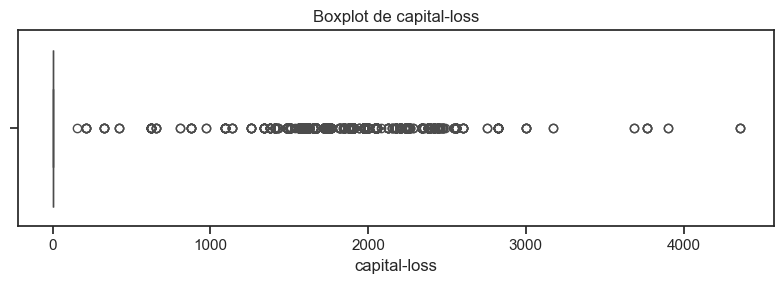

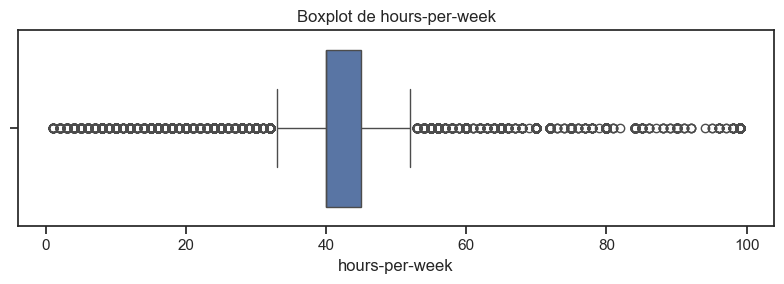

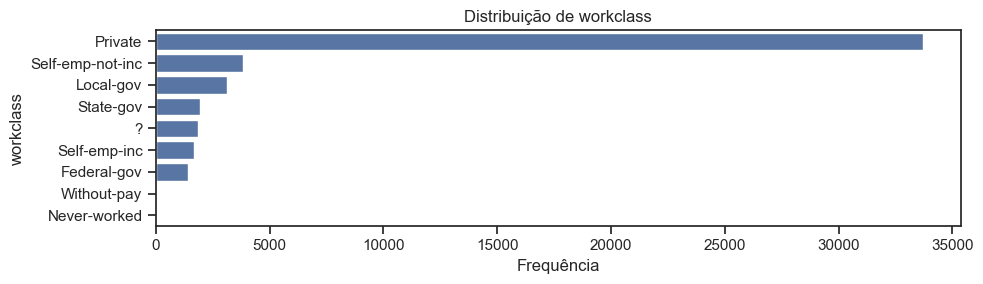

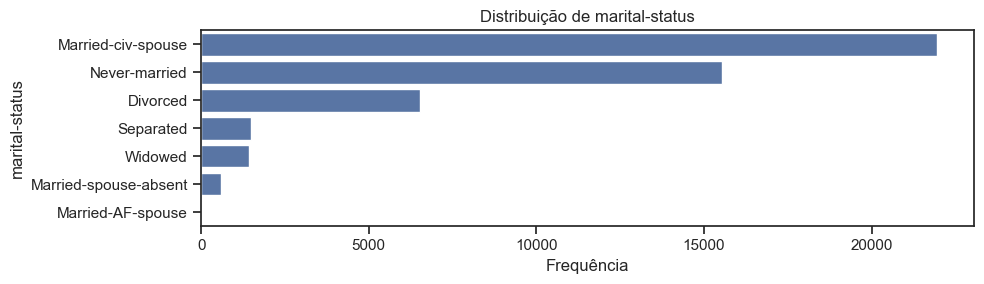

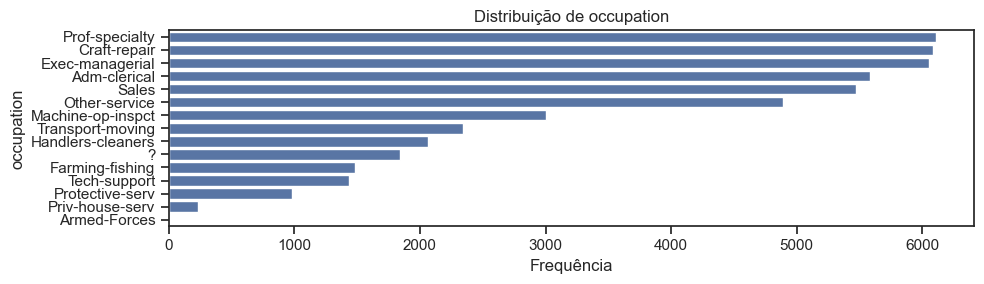

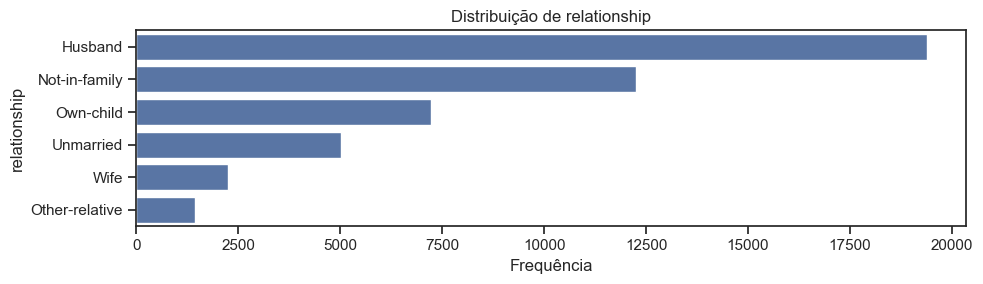

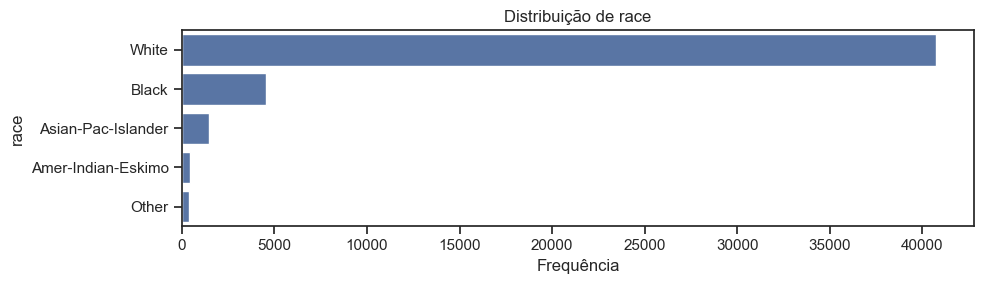

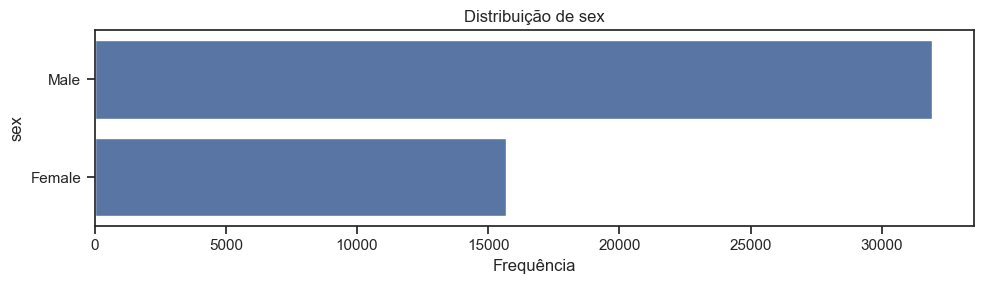

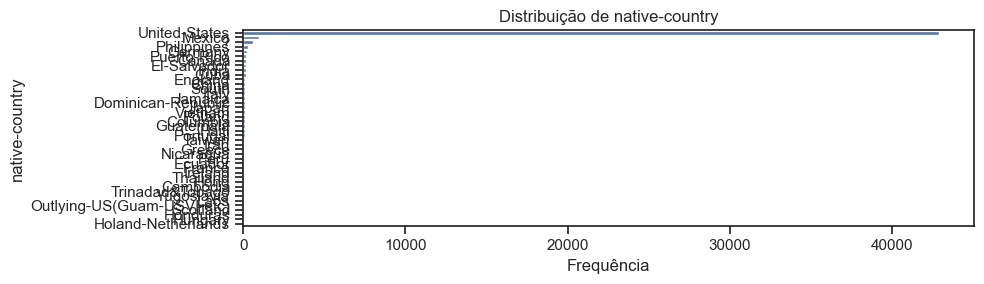

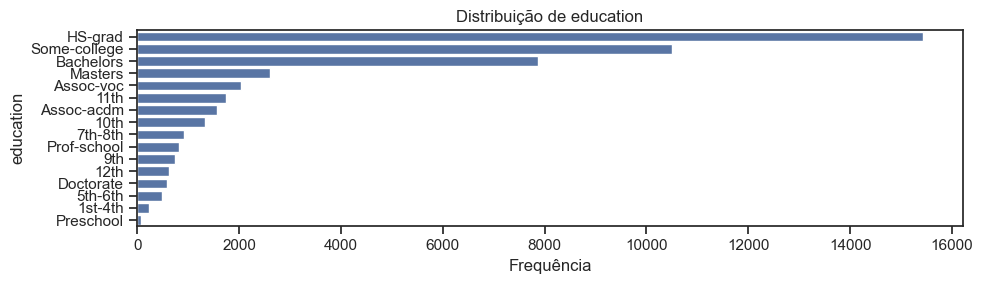

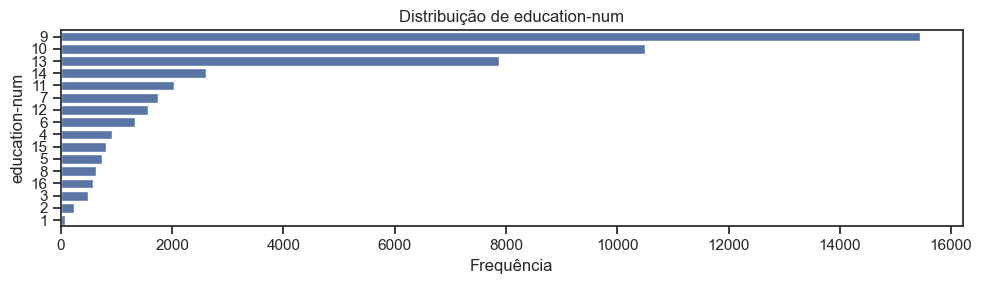

In [238]:
# Boxplot das variáveis numéricas (contínuas)
for col in continuas_razao:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Histogramas das variáveis categóricas (nominais e ordinais)
cat_cols = discretas_nominais + discretas_ordinais
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribuição de {col}')
    plt.xlabel('Frequência')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


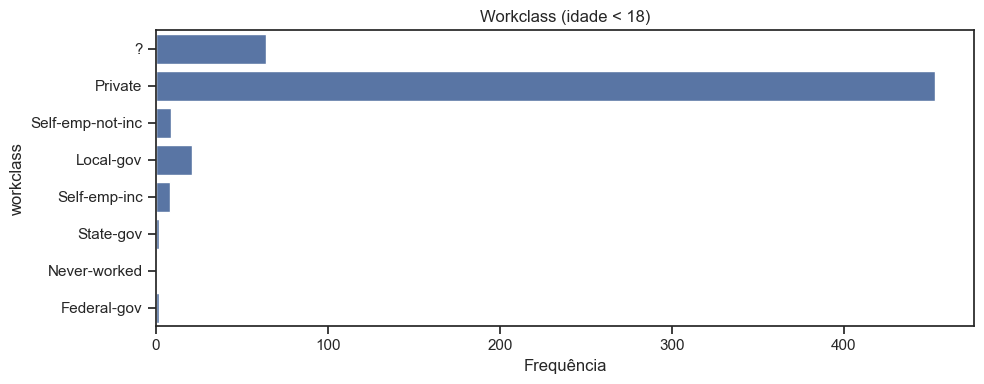

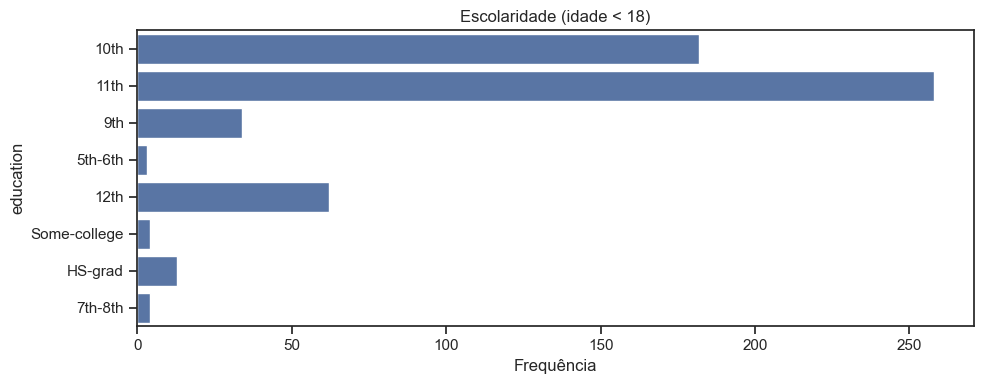

In [239]:
# Workclass e escolaridade para pessoas com menos de 18 anos
u18 = df[df['age'] < 18]

plt.figure(figsize=(10, 4))
sns.countplot(data=u18, y='workclass')
plt.title('Workclass (idade < 18)')
plt.xlabel('Frequência')
plt.ylabel('workclass')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=u18, y='education')
plt.title('Escolaridade (idade < 18)')
plt.xlabel('Frequência')
plt.ylabel('education')
plt.tight_layout()
plt.show()

In [240]:
# Valores únicos em colunas categóricas selecionadas
for col in ['native-country', 'occupation', 'workclass']:
    print(f"{col}: {df[col].nunique()} valores únicos")


native-country: 42 valores únicos
occupation: 15 valores únicos
workclass: 9 valores únicos


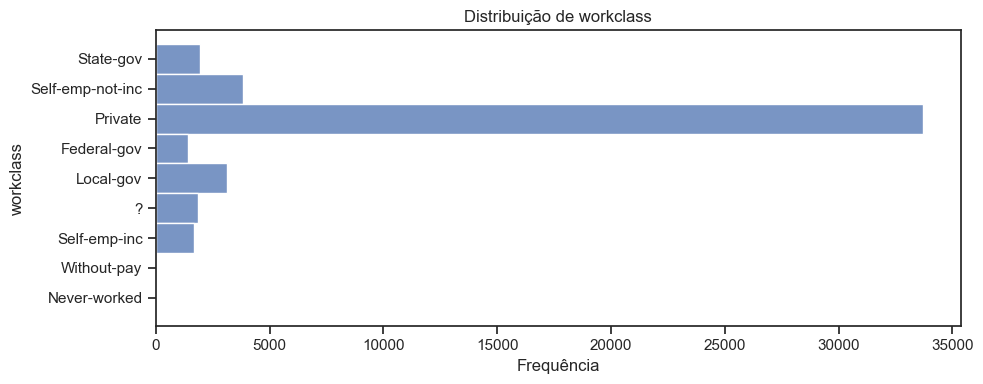

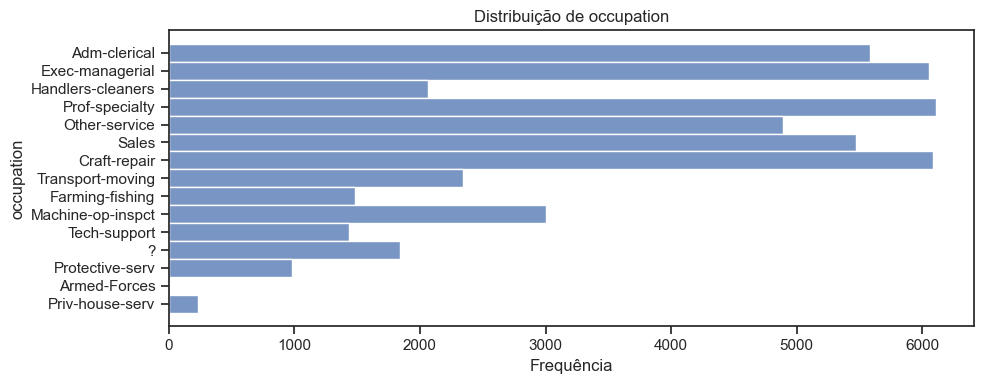

In [241]:
# Distribuição (histograma) de workclass
plt.figure(figsize=(10, 4))
sns.histplot(data=df, y='workclass')
plt.title('Distribuição de workclass')
plt.xlabel('Frequência')
plt.ylabel('workclass')
plt.tight_layout()
plt.show()

# Distribuição (histograma) de occupation
plt.figure(figsize=(10, 4))
sns.histplot(data=df, y='occupation')
plt.title('Distribuição de occupation')
plt.xlabel('Frequência')
plt.ylabel('occupation')
plt.tight_layout()
plt.show()


## Feature Engineering


**Significado de algumas categorias da coluna `education`**

- `Assoc-acdm`: curso de *Associate* de natureza acadêmica (equivalente a um tecnólogo/curso superior curto, tipicamente 2 anos).
- `Assoc-voc`: curso de *Associate* de natureza vocacional/técnica (formação mais voltada ao mercado de trabalho).
- `10th`: 10º ano do ensino médio (high school) nos EUA.
- `11th`: 11º ano do ensino médio (high school) nos EUA.
- `12th`: 12º ano do ensino médio (high school) nos EUA, geralmente o último ano antes da graduação.


In [242]:
# Agrupamento de níveis de educação
edu_map = {
    'Preschool': 'dropout',
    '1st-4th': 'dropout',
    '5th-6th': 'dropout',
    '7th-8th': 'dropout',
    '9th': 'dropout',
    '10th': 'dropout',
    '11th': 'dropout',
    '12th': 'dropout',
    'HS-Grad': 'HighGrad',
    'HS-grad': 'HighGrad',
    'Some-college': 'CommunityCollege',
    'Assoc-acdm': 'CommunityCollege',
    'Assoc-voc': 'CommunityCollege',
    'Bachelors': 'Bachelors',
    'Masters': 'Masters',
    'Prof-school': 'Masters',
    'Doctorate': 'Doctorate',
}
df['education'] = df['education'].replace(edu_map)

# Média de education-num por categoria após o agrupamento
edu_mean = (
    df[['education', 'education-num']]
        .groupby(['education'], as_index=False)
        .mean()
        .sort_values(by='education-num', ascending=True)
)

display(edu_mean)

# OrdinalEncoder em education com ordem baseada em education-num
edu_order = edu_mean['education'].tolist()
edu_encoder = OrdinalEncoder(categories=[edu_order])
df['education'] = edu_encoder.fit_transform(df[['education']]).astype(int)


,education,education-num
5,dropout,5.617480
3,HighGrad,9.000000
1,CommunityCollege,10.366260
0,Bachelors,13.000000
4,Masters,14.238915
2,Doctorate,16.000000


In [243]:
# drop education-num
df = df.drop(columns=['education-num'])

In [244]:
# Drop de fnlwgt
df = df.drop(columns=['fnlwgt'])
print('fnlwgt presente:', 'fnlwgt' in df.columns)


fnlwgt presente: False


In [245]:
# Label encoding para sex
df['sex'] = pd.Categorical(df['sex']).codes
print('sex codificado (exemplo):')
print(df['sex'].value_counts().sort_index())


sex codificado (exemplo):
sex
0    15674
1    31918
Name: count, dtype: int64


In [246]:
# Discretização de age em faixas (0-18 fixo, demais por quantis)
age = df['age']
mask_adult = age > 18

# Quantis para distribuir uniformemente as idades adultas
n_bins = 8
age_bin = pd.Series(index=df.index, dtype='object')
age_bin.loc[mask_adult] = pd.qcut(age[mask_adult], q=n_bins, duplicates='drop').astype(str)
age_bin.loc[~mask_adult] = '0-18'
df['age_bin'] = age_bin.astype('category')
print(df['age_bin'].value_counts().sort_index())

# Remoção de age após binarização
if 'age' in df.columns:
    df = df.drop(columns=['age'])
print('age presente:', 'age' in df.columns)


age_bin
(18.999, 24.0]    6642
(24.0, 29.0]      5957
(29.0, 33.0]      5124
(33.0, 38.0]      6436
(38.0, 43.0]      5827
(43.0, 48.0]      5115
(48.0, 56.0]      5742
(56.0, 90.0]      5392
0-18              1357
Name: count, dtype: int64
age presente: False


In [247]:
# Agrupamento de marital-status
marital_map = {
    'Never-married': 'NotMarried',
    'Married-AF-spouse': 'Married',
    'Married-civ-spouse': 'Married',
    'Married-spouse-absent': 'NotMarried',
    'Separated': 'Separated',
    'Divorced': 'Separated',
    'Widowed': 'Widowed',
}
df['marital-status'] = df['marital-status'].replace(marital_map)


**Categorias de marital-status**

- `Married-AF-spouse`: casado com cônjuge nas Forças Armadas dos EUA (AF = Armed Forces).
- `Married-civ-spouse`: casado com cônjuge civil (não militar).
- `Married-spouse-absent`: casado(a), mas o cônjuge está ausente (por separação de fato, trabalho, etc.).


In [248]:
# Discretização estatisticamente uniforme de hours-per-week (quantis)
# 5 grupos é um número razoável e mantém interpretabilidade
n_bins = 5
df['hours-per-week-bin'] = pd.qcut(df['hours-per-week'], q=n_bins, duplicates='drop')
print('Bins de hours-per-week:', df['hours-per-week-bin'].cat.categories)

# Remoção de hours-per-week após binarização
if 'hours-per-week' in df.columns:
    df = df.drop(columns=['hours-per-week'])
print('hours-per-week presente:', 'hours-per-week' in df.columns)


Bins de hours-per-week: IntervalIndex([(0.999, 35.0], (35.0, 40.0], (40.0, 50.0], (50.0, 99.0]], dtype='interval[float64, right]')
hours-per-week presente: False


In [249]:
# Snapshot do dataframe categórico antes do one-hot
df_cat = df.copy()


In [250]:
# Feature: capital-balance (capital-gain - capital-loss)
if 'capital-balance' not in df.columns:
    if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
        df['capital-balance'] = df['capital-gain'] - df['capital-loss']
    else:
        raise KeyError('capital-gain/capital-loss ausentes para criar capital-balance')

# Remoção de capital-gain e capital-loss após criar capital-balance
cols_to_drop = [c for c in ['capital-gain', 'capital-loss'] if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print('Colunas removidas:', cols_to_drop)


Colunas removidas: ['capital-gain', 'capital-loss']


In [251]:
# One-Hot Encoding para marital-status, relationship, race, native-country, occupation, workclass, age_bin e hours-per-week-bin
ohe_cols = ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass', 'age_bin', 'hours-per-week-bin']
df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)
print('One-hot aplicado em:', ohe_cols)
print('Colunas atuais:', len(df.columns))


One-hot aplicado em: ['marital-status', 'relationship', 'race', 'native-country', 'occupation', 'workclass', 'age_bin', 'hours-per-week-bin']
Colunas atuais: 98


In [252]:
# Preparação da target
target_col = y.columns[0]
df[target_col] = df[target_col].astype(str).str.strip().str.replace('.', '', regex=False)
vals = sorted(df[target_col].dropna().unique())
print('Valores da target:', vals)

if '>50K' in vals:
    target_positive = '>50K'
elif '1' in vals:
    target_positive = '1'
else:
    target_positive = vals[-1]

df['_target_bin'] = (df[target_col] == target_positive).astype(int)
df = df.drop(columns=[target_col])

print('Target positiva:', target_positive)
print(df['_target_bin'].value_counts())


Valores da target: ['<=50K', '>50K']
Target positiva: >50K
_target_bin
0    36053
1    11539
Name: count, dtype: int64


In [253]:
# Amostra do dataframe após o feature engineering
# Garante a target binária como última coluna
cols = [c for c in df.columns if c != '_target_bin'] + ['_target_bin']
df = df[cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)

df.head()


,education,sex,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,"age_bin_(18.999, 24.0]","age_bin_(24.0, 29.0]","age_bin_(29.0, 33.0]","age_bin_(33.0, 38.0]","age_bin_(38.0, 43.0]","age_bin_(43.0, 48.0]","age_bin_(48.0, 56.0]","age_bin_(56.0, 90.0]",age_bin_0-18,"hours-per-week-bin_(0.999, 35.0]","hours-per-week-bin_(35.0, 40.0]","hours-per-week-bin_(40.0, 50.0]","hours-per-week-bin_(50.0, 99.0]",_target_bin
0,3,1,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1,3,1,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0
2,1,1,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0
3,0,1,0,True,False,False,False,True,F

## Reparos

Checklist de colunas esperadas antes de rodar EDA/FE.


In [254]:
# Diagnóstico rápido de colunas esperadas
expected_cols = [
    "hours-per-week-bin", "marital-status", "relationship", "race", "sex",
    "workclass", "occupation", "native-country", "_target_bin"
]
missing = [c for c in expected_cols if c not in df.columns]
print('Colunas ausentes:', missing)

# Se alguma estiver ausente, rode a célula correspondente antes


Colunas ausentes: ['hours-per-week-bin', 'marital-status', 'relationship', 'race', 'workclass', 'occupation', 'native-country']


## EDA (pós-Feature Engineering)


In [255]:
# Helpers para correlação e distribuição por classe
from scipy.stats import chi2_contingency, pointbiserialr

sns.set_theme(style='whitegrid')

def cramers_v(col_a, col_b):
    ct = pd.crosstab(col_a, col_b)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    v = np.sqrt(phi2corr / max(1, min((kcorr - 1), (rcorr - 1))))
    return v, p, ct

def hist_by_class_num(col, bins=30, cap_upper=None, data=None):
    data = df if data is None else data
    data = data[[col, "_target_bin"]].copy()
    if cap_upper is not None:
        data[col] = data[col].clip(upper=cap_upper)

    plt.figure(figsize=(8, 4))
    sns.histplot(data=data, x=col, hue="_target_bin", bins=bins, kde=False, stat="count", common_norm=False)
    if cap_upper is not None:
        plt.axvline(cap_upper, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Distribuição de {col} por classe da target")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_dist_by_class(col, title, bins=30, cap_upper=None, data=None):
    data = df if data is None else data
    if "_target_bin" not in data.columns:
        data = data.copy()
        data["_target_bin"] = df["_target_bin"].values
    data = data[[col, "_target_bin"]].copy()
    if cap_upper is not None:
        data[col] = data[col].clip(upper=cap_upper)

    plt.figure(figsize=(8, 4))
    if pd.api.types.is_numeric_dtype(data[col]):
        sns.histplot(data=data, x=col, hue='_target_bin', bins=bins, kde=False, stat='count', common_norm=False)
        if cap_upper is not None:
            plt.axvline(cap_upper, color='gray', linestyle='--', linewidth=1)
            plt.title(f"{title} (>= {cap_upper} agrupado em {cap_upper}+")
            ax = plt.gca()
            ticks = sorted(set(list(ax.get_xticks()) + [cap_upper]))
            labels = [str(int(t)) if t != cap_upper else f"{int(cap_upper)}+" for t in ticks]
            ax.set_xticks(ticks)
            ax.set_xticklabels(labels)
        else:
            plt.title(title)
    else:
        sns.countplot(data=data, x=col, hue='_target_bin')
        plt.title(title)
        plt.xticks(rotation=45, ha='right')

    plt.xlabel(col)
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.show()


In [256]:
# Associação entre marital-status e relationship (Cramér's V)
v, p, ct = cramers_v(df_cat['marital-status'], df_cat['relationship'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
print('Contingência (linhas x colunas):', ct.shape)


Cramér's V: 0.624 | p-value: 0
Contingência (linhas x colunas): (4, 6)


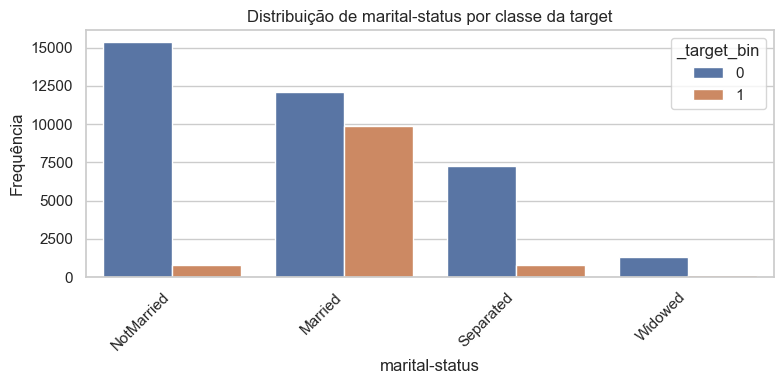

In [257]:
# Impacto de marital-status na target (distribuição por classe)
plot_dist_by_class('marital-status', 'Distribuição de marital-status por classe da target', data=df_cat)


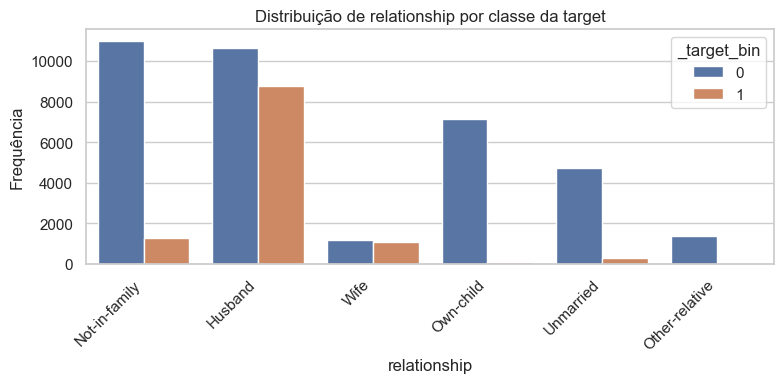

In [258]:
# Impacto de relationship na target (distribuição por classe)
plot_dist_by_class('relationship', 'Distribuição de relationship por classe da target', data=df_cat)


Cramér's V: 0.100 | p-value: 2.018e-102


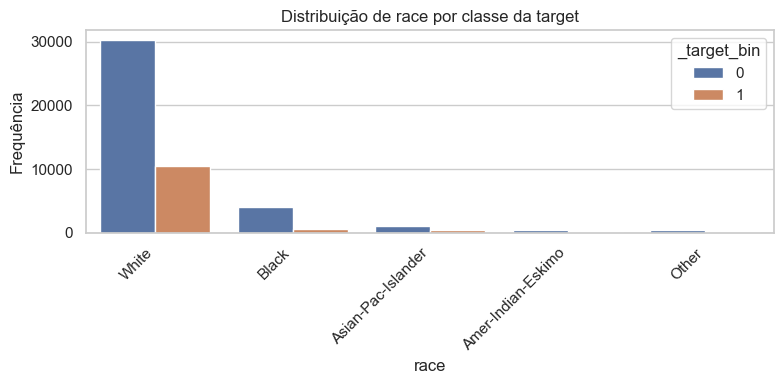

In [259]:
# Impacto de race na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['race'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('race', 'Distribuição de race por classe da target', data=df_cat)


Cramér's V: 0.215 | p-value: 0


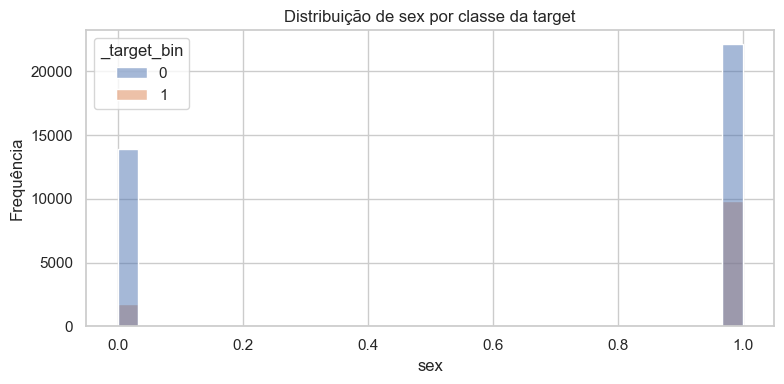

In [260]:
# Impacto de sex na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['sex'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('sex', 'Distribuição de sex por classe da target', data=df_cat)


Matriz de correlação (Pearson) - numéricas:
                 education       sex  capital-balance  _target_bin
education         1.000000  0.012688         0.128037     0.345377
sex               0.012688  1.000000         0.044714     0.215346
capital-balance   0.128037  0.044714         1.000000     0.213790
_target_bin       0.345377  0.215346         0.213790     1.000000


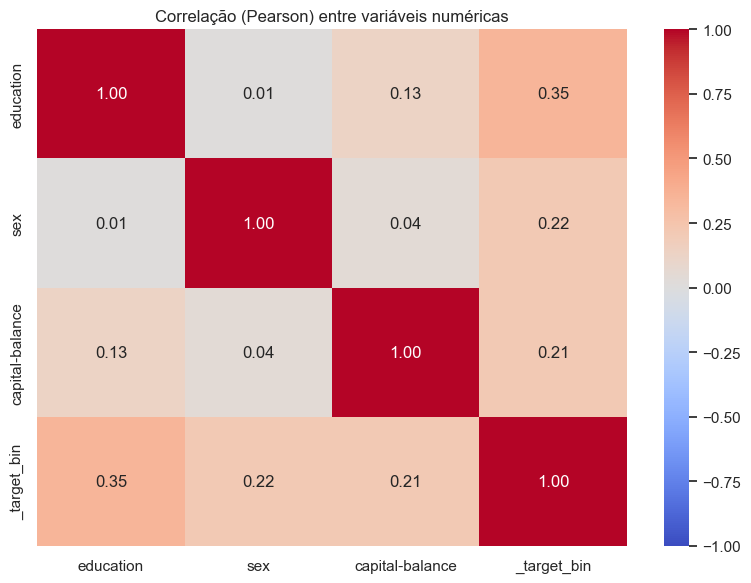

In [261]:
# Correlação entre variáveis numéricas (inclui target binária)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
corr = df[num_cols].corr(method='pearson')
print('Matriz de correlação (Pearson) - numéricas:')
print(corr)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação (Pearson) entre variáveis numéricas')
plt.tight_layout()
plt.show()


Cramér's V: 0.315 | p-value: 0


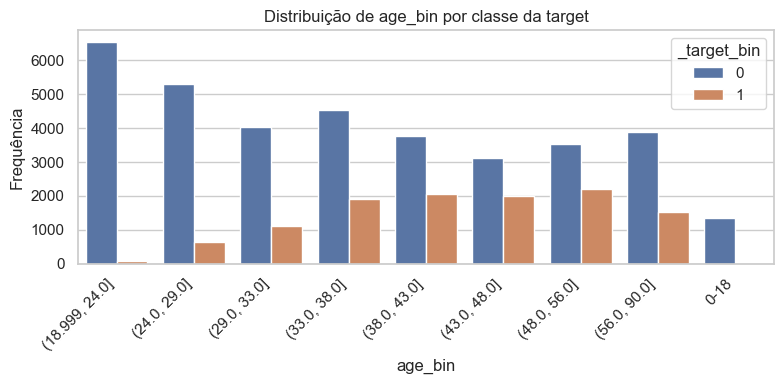

In [262]:
# Impacto de age_bin na target (Cramér's V + distribuição por classe)
v, p, _ = cramers_v(df_cat['age_bin'], df['_target_bin'])
print(f"Cramér's V: {v:.3f} | p-value: {p:.4g}")
plot_dist_by_class('age_bin', 'Distribuição de age_bin por classe da target', data=df_cat)


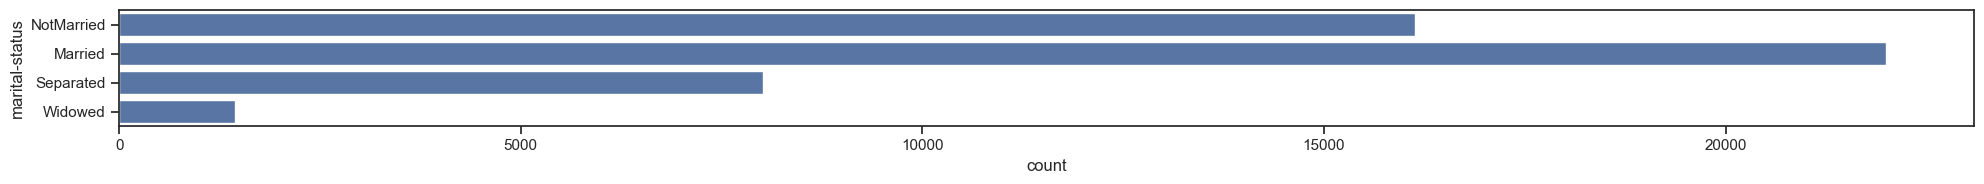

In [263]:
# Distribuição de marital-status
plt.figure(figsize=(20, 2))
sns.set_theme(style='ticks')
sns.countplot(y='marital-status', data=df_cat)
plt.tight_layout()
plt.show()


count    47592.000000
mean      1003.895508
std       7513.141794
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-balance, dtype: float64


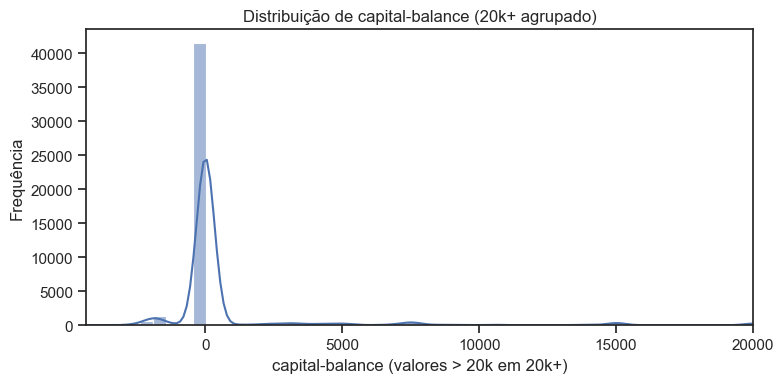

In [264]:
# Distribuição de capital-balance (com cap em 20k+)
print(df['capital-balance'].describe())
cb_clip = df['capital-balance'].clip(upper=20000)
plt.figure(figsize=(8, 4))
sns.histplot(cb_clip, bins=50, kde=True)
plt.title('Distribuição de capital-balance (20k+ agrupado)')
plt.xlabel('capital-balance (valores > 20k em 20k+)')
plt.ylabel('Frequência')
plt.xlim(cb_clip.min(), 20000)
plt.tight_layout()
plt.show()


Point-biserial: 0.214 | p-value: 0


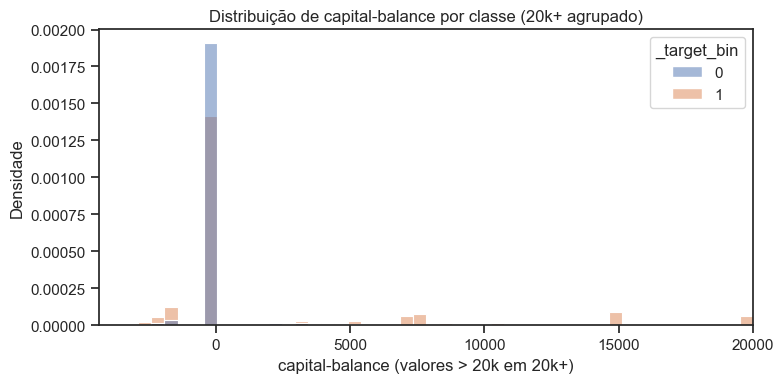

In [265]:
# Correlação de capital-balance com a target (point-biserial + distribuição por classe)
corr, p = pointbiserialr(df['_target_bin'], df['capital-balance'])
print(f"Point-biserial: {corr:.3f} | p-value: {p:.4g}")

cb_clip = df['capital-balance'].clip(upper=20000)
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df.assign(capital_balance_clip=cb_clip),
    x='capital_balance_clip',
    hue='_target_bin',
    bins=50,
    kde=False,
    stat='density',
    common_norm=False,
    alpha=0.5,
)
plt.title('Distribuição de capital-balance por classe (20k+ agrupado)')
plt.xlabel('capital-balance (valores > 20k em 20k+)')
plt.ylabel('Densidade')
plt.xlim(cb_clip.min(), 20000)
plt.tight_layout()
plt.show()


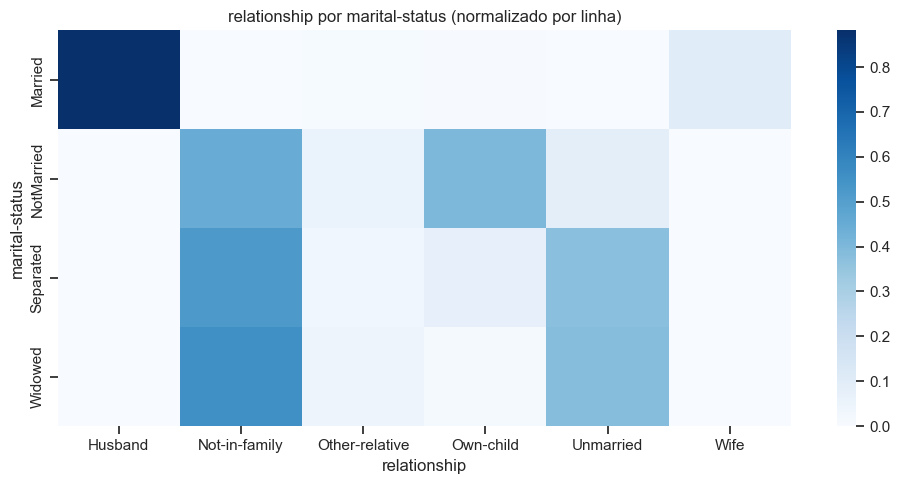

In [266]:
# Heatmap: relationship por marital-status (normalizado por linha)
ct = pd.crosstab(df_cat['marital-status'], df_cat['relationship'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
plt.figure(figsize=(10, 5))
sns.heatmap(ct_norm, cmap='Blues')
plt.title('relationship por marital-status (normalizado por linha)')
plt.xlabel('relationship')
plt.ylabel('marital-status')
plt.tight_layout()
plt.show()


In [267]:
df.head()

,education,sex,capital-balance,marital-status_Married,marital-status_NotMarried,marital-status_Separated,marital-status_Widowed,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_?,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,"age_bin_(18.999, 24.0]","age_bin_(24.0, 29.0]","age_bin_(29.0, 33.0]","age_bin_(33.0, 38.0]","age_bin_(38.0, 43.0]","age_bin_(43.0, 48.0]","age_bin_(48.0, 56.0]","age_bin_(56.0, 90.0]",age_bin_0-18,"hours-per-week-bin_(0.999, 35.0]","hours-per-week-bin_(35.0, 40.0]","hours-per-week-bin_(40.0, 50.0]","hours-per-week-bin_(50.0, 99.0]",_target_bin
0,3,1,2174,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0
1,3,1,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,0
2,1,1,0,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,0
3,0,1,0,True,False,False,False,True,F